# 5. Improving a Model.

Frist predictions = baseline predictions.

First model = baseline model.

#### From a data perspective:
* Could we collect more data ? (generally, the more data, the better)
* Could we improve our data ? (more features = more insights)

#### From a model prespective:
* Is there a better model we can use ?
* Could we improve the current model ?

Hyperparameters vs Parameters
* **Parameters** = model find these pattterns in the data.
* **Hyperparameters** = settings on a model we can adjust to (potentially) improve its ability to find patterns.

#### Three ways to adjust hyperparameters:
1. By hand.
2. Randomly with RandomSearchCV.
3. Exhaustively with GridSearchCV.

In [1]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

In [2]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

# Tuning Hyperparameters 1

### 5.1 Tuning Hyperparameters by Hand.

Let's make 3 sets: Training, Validation and Test.

In [3]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

We're going to try and adjust:

* `max_depth`
* `max_features`
* `min_sample_leaf`
* `min_sample_split`
* `n_estimators`

In [4]:
import numpy as np
import pandas as pd

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
heart_disease = pd.read_csv("./data/heart-disease.csv")

heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
def evaluation_preds(y_true, y_preds):
    """
    Perfroms evaluation comparison on y_true labels vs y_preds labels
    on a classification model.
    """

    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {"accuracy": round(accuracy, 2), 
                   "precision": round(precision, 2),
                    "recall": round(recall, 2),
                    "f1": round(f1, 2)
                   }
    print(f"Acc: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 score: {f1:.2f}")

    return metric_dict

In [8]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# shuffle the data.
heart_disease_shuffled = heart_disease.sample(frac = 1)

# split the data into X & y.
X = heart_disease_shuffled.drop("target", axis = 1)
y = heart_disease_shuffled["target"]

# Split the data into train, validation & test sets.
train_split = round(0.7 * len(heart_disease_shuffled))  # 70% of data.
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled))   # 15% of data.
print(train_split, valid_split)

X_train, y_train = X[:train_split], y[:train_split]
X_valid, y_valid = X[train_split:valid_split], y[train_split:valid_split]
X_test, y_test = X[valid_split:], y[valid_split:]

print(len(heart_disease_shuffled), len(X_train), len(X_valid), len(X_test))

# Creating and Fitting the model.
clf = RandomForestClassifier(n_estimators=10)
clf.fit(X_train, y_train)

212 257
303 212 45 46


,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# Make predictions
y_preds = clf.predict(X_valid)

# Evaluate the classifier on validation set
baseline_metrics = evaluation_preds(y_valid, y_preds)
baseline_metrics

Acc: 80.00%
Precision: 0.77
Recall: 0.92
F1 score: 0.84


{'accuracy': 0.8, 'precision': 0.77, 'recall': 0.92, 'f1': 0.84}

In [10]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 10,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [11]:
np.random.seed(42)

# Create a second classifier with different hyperparameters.
clf_2 = RandomForestClassifier(n_estimators=100)
clf_2.fit(X_train, y_train)

# Make predictions
y_preds = clf_2.predict(X_valid)

# Evaluate the classifier on validation set
clf_2_metrics = evaluation_preds(y_valid, y_preds)

Acc: 82.22%
Precision: 0.84
Recall: 0.84
F1 score: 0.84


In [12]:
np.random.seed(42)

# Create a third classifier with different hyperparameters.
clf_3 = RandomForestClassifier(n_estimators=100, max_depth=10)
clf_3.fit(X_train, y_train)

# Make predictions
y_preds = clf_3.predict(X_valid)

# Evaluate the classifier on validation set
clf_3_metrics = evaluation_preds(y_valid, y_preds)

Acc: 80.00%
Precision: 0.81
Recall: 0.84
F1 score: 0.82


# Tuning Hyperparameters 2 (RandomizedSearchCV)

### 5.2 Hyperparameter tuning with RandomizedSearchCV

In [13]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

grid = {"n_estimators": [10, 100, 200, 500, 1000, 1200],
        "max_depth": [None, 5, 10, 20, 30],
        "max_features": ["log2", "sqrt"],
        "min_samples_split": [2, 4, 6],
        "min_samples_leaf": [1, 2, 4]
}

np.random.seed(42)

# Split the data into X & y.
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestClassifier
clf = RandomForestClassifier(n_jobs=1)

# Setup RandomizedSearchCV
rs_clf = RandomizedSearchCV(estimator=clf, 
                            param_distributions=grid, 
                            n_iter=10, # Number of models to try
                            cv=5,
                            verbose=2)

# Fit the RandomizedSearchCV version of clf
rs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.8s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=4, n_estimators=100

,estimator,RandomForestC...fier(n_jobs=1)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [14]:
# Get the best parameters.
rs_clf.best_params_

{'n_estimators': 200,
 'min_samples_split': 6,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [15]:
rs_clf.get_params()

{'cv': 5,
 'error_score': nan,
 'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': None,
 'estimator__max_features': 'sqrt',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': 1,
 'estimator__oob_score': False,
 'estimator__random_state': None,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': RandomForestClassifier(n_jobs=1),
 'n_iter': 10,
 'n_jobs': None,
 'param_distributions': {'n_estimators': [10, 100, 200, 500, 1000, 1200],
  'max_depth': [None, 5, 10, 20, 30],
  'max_features': ['log2', 'sqrt'],
  'min_samples_split': [2, 4, 6],
  'min_samples_leaf': [1, 2, 4]},
 'pre_dispatch': '2*n_jobs',
 'ra

In [16]:
# Make predictions with the best hyperparameters
rs_y_preds = rs_clf.predict(X_test)

# Evaluate the predictions
rs_metrics = evaluation_preds(y_test, rs_y_preds)

Acc: 81.97%
Precision: 0.77
Recall: 0.86
F1 score: 0.81


# Tuning Hyperparameters 3 (GridSearchCV)

### 5.3 Hyperparameter tuning with GridSearchCV

In [17]:
grid

{'n_estimators': [10, 100, 200, 500, 1000, 1200],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['log2', 'sqrt'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

In [18]:
6 * 5 * 2 * 3 * 3 * 5

2700

In [19]:
grid_2 = {"n_estimators": [100, 200, 500],
        "max_depth": [None],
        "max_features": ["log2", "sqrt"],
        "min_samples_split": [6],
        "min_samples_leaf": [1, 2]
}

In [20]:
3 * 1 * 2 * 1 * 2 * 5 

60

In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split

np.random.seed(42)

# Split the data into X & y.
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestClassifier
clf = RandomForestClassifier(n_jobs=1)

# Setup GridSearchCV
gs_clf = GridSearchCV(estimator=clf, 
                            param_grid=grid_2,
                            cv=5,
                            verbose=2)

# Fit the GridSearchCV version of clf
gs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=6, 

,estimator,RandomForestC...fier(n_jobs=1)
,param_grid,"{'max_depth': [None], 'max_features': ['log2', 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [6], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [22]:
# Get the best parameters.
gs_clf.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 6,
 'n_estimators': 200}

In [23]:
gs_clf.get_params()

{'cv': 5,
 'error_score': nan,
 'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__class_weight': None,
 'estimator__criterion': 'gini',
 'estimator__max_depth': None,
 'estimator__max_features': 'sqrt',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': 1,
 'estimator__oob_score': False,
 'estimator__random_state': None,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': RandomForestClassifier(n_jobs=1),
 'n_jobs': None,
 'param_grid': {'n_estimators': [100, 200, 500],
  'max_depth': [None],
  'max_features': ['log2', 'sqrt'],
  'min_samples_split': [6],
  'min_samples_leaf': [1, 2]},
 'pre_dispatch': '2*n_jobs',
 'refit': True,
 'return_train_score': False,
 'scoring': None,
 've

In [24]:
# Make predictions with the best hyperparameters
gs_y_preds = gs_clf.predict(X_test)

# Evaluate the predictions
gs_metrics = evaluation_preds(y_test, gs_y_preds)

Acc: 78.69%
Precision: 0.74
Recall: 0.82
F1 score: 0.78


Let's compare our different models metrics.

In [25]:
compare_metrics = pd.DataFrame({"baseline": baseline_metrics,
                                "clf_2": clf_2_metrics,
                                "clf_3": clf_3_metrics,
                                "random search": rs_metrics,
                                "grid search": gs_metrics})
compare_metrics

,baseline,clf_2,clf_3,random search,grid search
accuracy,0.80,0.82,0.80,0.82,0.79
precision,0.77,0.84,0.81,0.77,0.74
recall,0.92,0.84,0.84,0.86,0.82
f1,0.84,0.84,0.82,0.81,0.78


<Axes: >

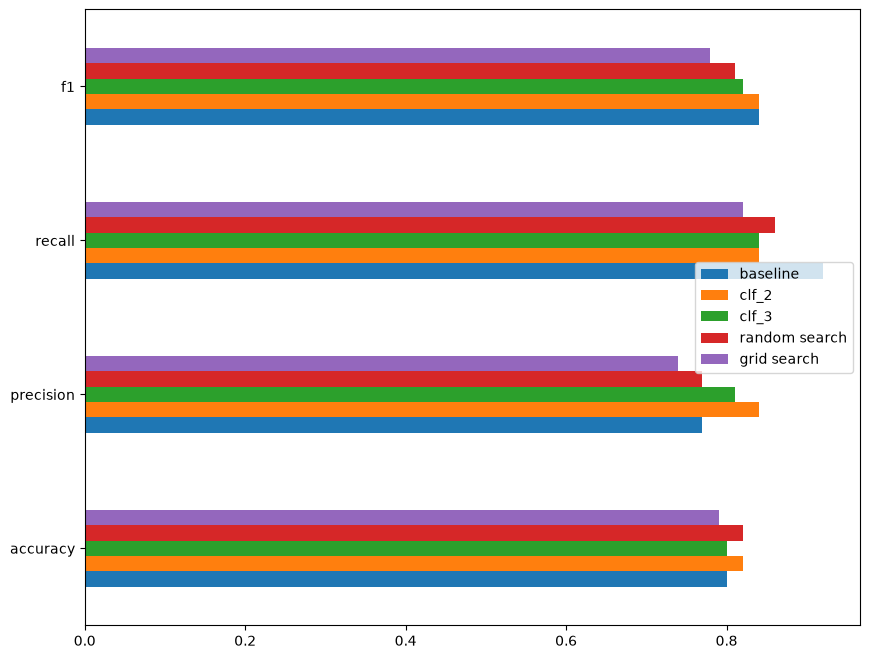

In [26]:
compare_metrics.plot.barh(figsize=(10,8))

# 6. Saving and loading trained machine learning models

Two ways to save and load machine learning models:
1. with Python's `pickle` module.
2. with the `joblib` module.

## 6.1 **Pickle**

In [27]:
import pickle

# Save an exsisting model to file
pickle.dump(gs_clf, open("./model/gs_random_forest_model_1.pkl", "wb"))

In [28]:
# Load a saved model
loaded_pickle_model = pickle.load(open("./model/gs_random_forest_model_1.pkl", "rb"))

In [29]:
# Make some predictions
pickle_y_preds = loaded_pickle_model.predict(X_test)
evaluation_preds(y_test, pickle_y_preds)

Acc: 78.69%
Precision: 0.74
Recall: 0.82
F1 score: 0.78


{'accuracy': 0.79, 'precision': 0.74, 'recall': 0.82, 'f1': 0.78}

## 6.2 **Joblib**

In [35]:
from joblib import dump, load

# Save model to file
dump(gs_clf, filename="./model/gs_random_forest_model_1.joblib")

['./model/gs_random_forest_model_1.joblib']

In [38]:
# Import the saved joblib model.
loaded_joblib_model = load(filename="./model/gs_random_forest_model_1.joblib")

In [39]:
# Make and evaluate joblib predictions
joblib_y_preds = loaded_joblib_model.predict(X_test)
evaluation_preds(y_test, joblib_y_preds)

Acc: 78.69%
Precision: 0.74
Recall: 0.82
F1 score: 0.78


{'accuracy': 0.79, 'precision': 0.74, 'recall': 0.82, 'f1': 0.78}

### If the Model is large, it's always better to use `Joblib`, instead of pickle.